Time Series Revenue Forecast -- Sony

Sony Group Corporation, tic = SONY

- Data: quarterly consolidated net revenue in USD millions, for 32 quarters ending 2017-12-31 through 2025-09-30. Sourced the data from: Macrotrends-compiled company financial statements.
- Sony's fiscal year is from April-March. Fiscal Q3 (Oct to Dec) is holiday season. (1st dv)
- PS5 console launch happened in 2020, so expect spike in overall revenues from then on! (2nd dv)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# get rid of scientific notation
pd.options.display.float_format = '{:.2F}'.format

qsales = pd.read_csv('sony_qrevenue.csv')

display(qsales)

,datadate,revenue_musd,tic,calquarter
0,2017-12-31,23784,SONY,4
1,2018-03-31,17826,SONY,1
2,2018-06-30,17973,SONY,2
3,2018-09-30,19645,SONY,3
4,2018-12-31,21376,SONY,4
5,2019-03-31,18997,SONY,1
6,2019-06-30,17524,SONY,2
7,2019-09-30,19737,SONY,3
8,2019-12-31,22661,SONY,4
9,2020-03-31,16069,SONY,1


In [ ]:
# change date to datetime type

qsales['datadate'] = pd.to_datetime(qsales['datadate'])

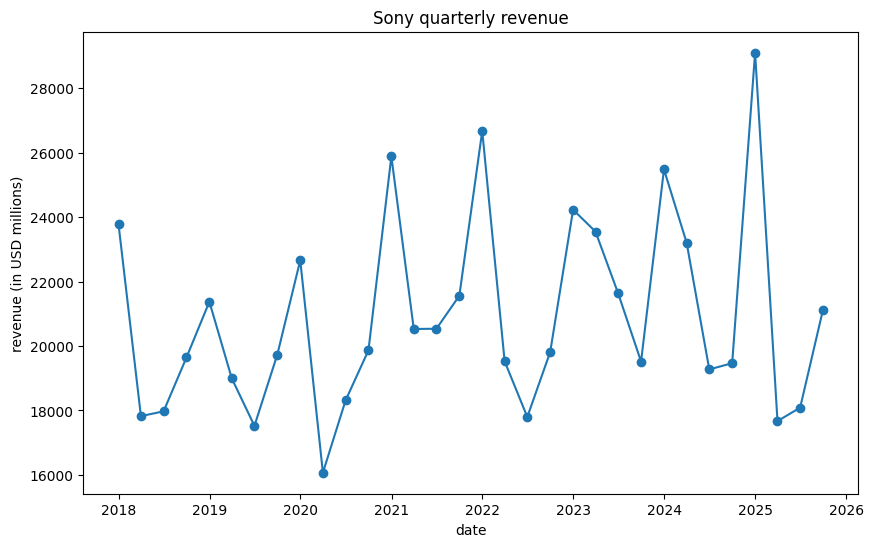

In [ ]:
# visualize the data
plt.figure(figsize=(10,6))

plt.title('Sony quarterly revenue')

plt.ylabel('revenue (in USD millions)')
plt.xlabel('date')

plt.plot(qsales['datadate'], qsales['revenue_musd'], marker='o')

#plot patterns:
- upward trend over time (can see from comparing the heights of each peak)
- a cyclical spiking every 4th quarter (sony's fiscal Q3, Oct-Dec, during the holiday quarter). 4th quarter is the dummy variable.
- ps5 launched 2020, so general increase in revenues starting 2020 with the new console + accessories + games sales!!

In [ ]:
# to introduce the time component of time series regression forecasting,
# all we have to do is add a new column - call it time - and measure incremently increasing time periods (1,2,3,...)

# base requirement is that each row represents an equal block of time (each row is a quarter)

qsales['time'] = range(1, len(qsales) + 1)
# remember: to make range inclusive of the end, end of range is length + 1

display(qsales)

,datadate,revenue_musd,tic,calquarter,time
0,2017-12-31,23784,SONY,4,1
1,2018-03-31,17826,SONY,1,2
2,2018-06-30,17973,SONY,2,3
3,2018-09-30,19645,SONY,3,4
4,2018-12-31,21376,SONY,4,5
5,2019-03-31,18997,SONY,1,6
6,2019-06-30,17524,SONY,2,7
7,2019-09-30,19737,SONY,3,8
8,2019-12-31,22661,SONY,4,9
9,2020-03-31,16069,SONY,1,10


In [ ]:
# take 75% and 25% of the dataset

dt4training = qsales[:int(0.75 * (len(qsales) + 1))] # takes the first 75% of rows
dt4testing = qsales[(int(0.75 * (len(qsales) + 1))):] # takes last 25% of rows

In [ ]:
# baseline time series model for regression analysis (w/o dv)

y = dt4training.loc[:, 'revenue_musd']
x = dt4training.loc[:, 'time']

x = sm.add_constant(x)

model1 = sm.OLS(y,x).fit()
model1.params

,0
const,19329.64
time,103.75


^^ revenue = 19329.64 + 103.75 * time

In [ ]:
# calculate baseline MAPE for later comparison
x_test_baseline = dt4testing.loc[:, 'time']
x_test_baseline = sm.add_constant(x_test_baseline)

model1_assessment = dt4testing.copy()
model1_assessment['predicted_revenue'] = model1.predict(x_test_baseline)

model1_assessment['abs_pct_error'] = abs(
    (model1_assessment['revenue_musd'] - model1_assessment['predicted_revenue'])
    / model1_assessment['revenue_musd']
    )

display(model1_assessment)

,datadate,revenue_musd,tic,calquarter,time,predicted_revenue,abs_pct_error
24,2023-12-31,25483,SONY,4,25,21923.44,0.14
25,2024-03-31,23208,SONY,1,26,22027.19,0.05
26,2024-06-30,19275,SONY,2,27,22130.94,0.15
27,2024-09-30,19468,SONY,3,28,22234.69,0.14
28,2024-12-31,29103,SONY,4,29,22338.45,0.23
29,2025-03-31,17671,SONY,1,30,22442.20,0.27
30,2025-06-30,18089,SONY,2,31,22545.95,0.25
31,2025-09-30,21134,SONY,3,32,22649.70,0.07


In [ ]:
model1_assessment['abs_pct_error'].mean()

np.float64(0.16267392759819496)

In [ ]:
# forecast time series model w/ 80% confidence interval

model1_prediction_results = model1.get_prediction(x)
prediction_intervals = model1_prediction_results.summary_frame(alpha=0.2) # 80% confidence

display(prediction_intervals)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,19433.40,1056.50,18037.51,20829.28,15640.54,23226.25
1,19537.15,989.90,18229.26,20845.04,15775.79,23298.51
2,19640.90,925.20,18418.50,20863.30,15908.41,23373.39
3,19744.65,862.83,18604.65,20884.65,16038.33,23450.98
4,19848.40,803.34,18787.01,20909.80,16165.50,23531.31
5,19952.16,747.40,18964.66,20939.65,16289.86,23614.45
6,20055.91,695.89,19136.47,20975.35,16411.38,23700.44
7,20159.66,649.86,19301.04,21018.27,16530.00,23789.32
8,20263.41,610.53,19456.75,21070.07,16645.69,23881.14
9,20367.16,579.29,19601.78,21132.55,16758.42,23975.91


## Adding the holiday-quarter dummy variable

- FIRST DV: check for calquarter == 4 (Oct-Dec, Sony's fiscal Q3 / holiday quarter)

We'll also add an interaction term (time * dummy) the same way the class example did with iphone_interaction, in case the holiday effect is growing or shrinking over time.

In [ ]:
qsales['holiday_dv'] = np.where(qsales['calquarter'] == 4, 1, 0)

qsales['holiday_interaction'] = qsales['time'] * qsales['holiday_dv']

qsales['ps5_dv'] = np.where(qsales['datadate'] >= '2020-10-01', 1, 0)

qsales['ps5_interaction'] = qsales['time'] * qsales['ps5_dv']

display(qsales)

,datadate,revenue_musd,tic,calquarter,time,holiday_dv,holiday_interaction,ps5_dv,ps5_interaction
0,2017-12-31,23784,SONY,4,1,1,1,0,0
1,2018-03-31,17826,SONY,1,2,0,0,0,0
2,2018-06-30,17973,SONY,2,3,0,0,0,0
3,2018-09-30,19645,SONY,3,4,0,0,0,0
4,2018-12-31,21376,SONY,4,5,1,5,0,0
5,2019-03-31,18997,SONY,1,6,0,0,0,0
6,2019-06-30,17524,SONY,2,7,0,0,0,0
7,2019-09-30,19737,SONY,3,8,0,0,0,0
8,2019-12-31,22661,SONY,4,9,1,9,0,0
9,2020-03-31,16069,SONY,1,10,0,0,0,0


In [ ]:
# this is how to take 75% and 25% of the dataset (re-split now that the dummy columns exist)

dt4training = qsales[:int(0.75 * (len(qsales) + 1))] # takes the first 75% of rows
dt4testing = qsales[(int(0.75 * (len(qsales) + 1))):] # takes last 25% of rows

In [ ]:
# train model with the dummy variable and interaction term

x = dt4training.loc[:, ['time', 'holiday_dv', 'holiday_interaction', 'ps5_dv', 'ps5_interaction']]
x = sm.add_constant(x, has_constant='add')

y = dt4training.loc[:, 'revenue_musd']

model_dummy = sm.OLS(y,x).fit()

model_dummy.params

,0
const,18416.72
time,-10.94
holiday_dv,4491.13
holiday_interaction,9.95
ps5_dv,2621.87
ps5_interaction,-12.38


revenue = 18416.72 - 10.94(time) + 44191.13(holiday_dv) + 9.95(holiday_interaction) + 2621.87(ps5_dv) - 12.38(ps5_interaction)

In [ ]:
# to forecast values, first prepare the testing independent variables (time, dummys, interactions)
# then use the get_prediction function to forecast the values into the testing set

x_test = dt4testing.loc[:, ['time', 'holiday_dv', 'holiday_interaction', 'ps5_dv', 'ps5_interaction']]
x_test = sm.add_constant(x_test, has_constant='add')

In [ ]:
test_predictions = model_dummy.get_prediction(x_test).summary_frame(alpha=0.2) # w/ 80% confidence level

display(test_predictions)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
24,25195.47,1711.91,22917.97,27472.98,22161.64,28229.30
25,20432.29,1056.83,19026.29,21838.29,17984.04,22880.54
26,20408.97,1171.71,18850.13,21967.80,17869.86,22948.07
27,20385.65,1289.11,18670.63,22100.66,17747.78,23023.52
28,25141.99,2308.18,22071.21,28212.78,21475.00,28808.98
29,20339.01,1529.10,18304.70,22373.32,17483.23,23194.79
30,20315.69,1650.95,18119.28,22512.10,17342.26,23289.12
31,20292.37,1773.69,17932.67,22652.07,17196.36,23388.38


## Checking accuracy w/ MAPE

MAPE tells us on average how far our forecasts are from the actual values (percentage).
- Lower is better.
- Compare the baseline (time-only) model against the dummy-variable model to see which one predicts the test set better.

In [ ]:
model_dummy_assessment = dt4testing.copy()
model_dummy_assessment['predicted_revenue'] = test_predictions['mean']

model_dummy_assessment['abs_pct_error'] = abs(
    (model_dummy_assessment['revenue_musd'] - model_dummy_assessment['predicted_revenue'])
    / model_dummy_assessment['revenue_musd']
    )

display(model_dummy_assessment)

,datadate,revenue_musd,tic,calquarter,time,holiday_dv,holiday_interaction,ps5_dv,ps5_interaction,predicted_revenue,abs_pct_error
24,2023-12-31,25483,SONY,4,25,1,25,1,25,25195.47,0.01
25,2024-03-31,23208,SONY,1,26,0,0,1,26,20432.29,0.12
26,2024-06-30,19275,SONY,2,27,0,0,1,27,20408.97,0.06
27,2024-09-30,19468,SONY,3,28,0,0,1,28,20385.65,0.05
28,2024-12-31,29103,SONY,4,29,1,29,1,29,25141.99,0.14
29,2025-03-31,17671,SONY,1,30,0,0,1,30,20339.01,0.15
30,2025-06-30,18089,SONY,2,31,0,0,1,31,20315.69,0.12
31,2025-09-30,21134,SONY,3,32,0,0,1,32,20292.37,0.04


In [ ]:
model_dummy_assessment['abs_pct_error'].mean()

np.float64(0.08585715984514472)

^^ MAPE = 8.59%

## Model -- Forecast next 4 quarters

forecast revenue for the next 4 quarters. next 4 quarters are:
- Dec-1-2025 to Feb-29-2026 (holiday quarter) (Q1),
- Mar-1-2026 to May-31-2026,
- Jun-1-2026 to Aug-31-2026, and
- Sep-1-2026 to Nov-30-2026 (Q4).

In [ ]:
# retrain full dataset before forecasting forward

x_full = qsales.loc[:, ['time', 'holiday_dv', 'holiday_interaction', 'ps5_dv', 'ps5_interaction']]
x_full = sm.add_constant(x_full, has_constant='add')

y_full = qsales.loc[:, 'revenue_musd']

model_final = sm.OLS(y_full, x_full).fit()

model_final.params

,0
const,18816.75
time,-52.56
holiday_dv,3407.40
holiday_interaction,123.10
ps5_dv,2395.45
ps5_interaction,9.21


In [ ]:

last_time = qsales['time'].max()

future = pd.DataFrame({
    'datadate': pd.to_datetime(['2025-12-31', '2026-03-31', '2026-06-30', '2026-09-30']),
    'time': [last_time + 1, last_time + 2, last_time + 3, last_time + 4],
})

future['calquarter'] = future['datadate'].dt.quarter
future['holiday_dv'] = np.where(future['calquarter'] == 4, 1, 0)
future['holiday_interaction'] = future['time'] * future['holiday_dv']
future['ps5_dv'] = np.where(future['datadate'] >= '2020-10-01', 1, 0)
future['ps5_interaction'] = future['time'] * future['ps5_dv']

display(future)

,datadate,time,calquarter,holiday_dv,holiday_interaction,ps5_dv,ps5_interaction
0,2025-12-31,33,4,1,33,1,33
1,2026-03-31,34,1,0,0,1,34
2,2026-06-30,35,2,0,0,1,35
3,2026-09-30,36,3,0,0,1,36


In [ ]:
x_future = future.loc[:, ['time', 'holiday_dv', 'holiday_interaction', 'ps5_dv', 'ps5_interaction']]
x_future = sm.add_constant(x_future, has_constant='add')

future_forecast = model_final.get_prediction(x_future).summary_frame(alpha=0.2) # 80% confidence level


display(future_forecast)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,27251.25,1427.70,25373.86,29128.64,24388.94,30113.56
1,19738.23,861.97,18604.76,20871.70,17298.36,22178.10
2,19694.88,919.89,18485.25,20904.50,17218.71,22171.05
3,19651.52,978.77,18364.47,20938.58,17136.62,22166.43


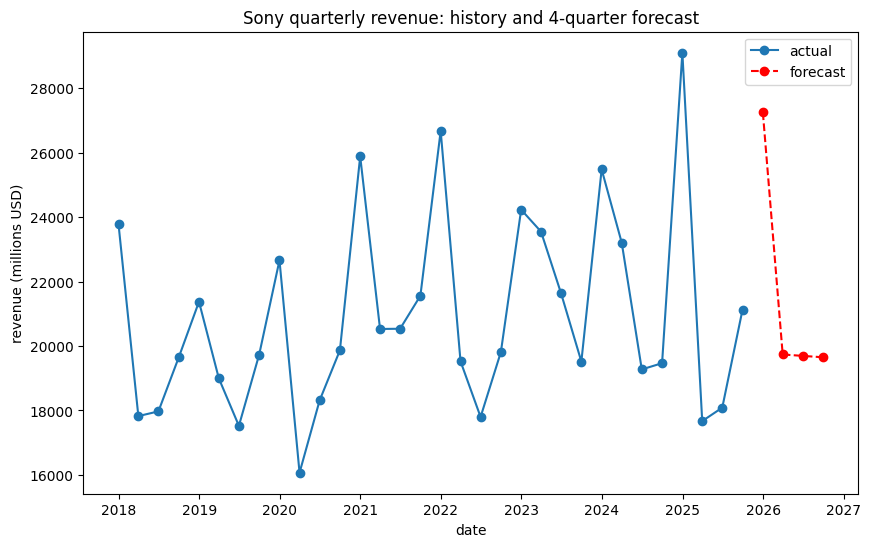

In [ ]:
# quick visual of history + forecast

plt.figure(figsize=(10,6))
plt.title('Sony quarterly revenue: history and 4-quarter forecast')
plt.ylabel('revenue (millions USD)')
plt.xlabel('date')

plt.plot(qsales['datadate'], qsales['revenue_musd'], marker='o', label='actual')
plt.plot(future['datadate'], future_forecast['mean'], marker='o', linestyle='--', color='red', label='forecast')
plt.legend()

^^ observations
- every December/holiday season, you can see the massive spike in revenue followed by the sharp drop in revenues in the next quarter starting around March.
- this stays true in the forecast.

## Memo: time-series model and predictive capability

**Company:** Sony Group Corporation (SONY)

**Data:** 32 quarters of net revenue (fiscal Q4-2017 until Q2-2026, Dec-2017 through Sep-2025) (in millions of USD).

**Data Preparation:**
- Added a *time* variable (1, 2, 3, 4) to see data across fiscal quarters (the baseline model).
- Visualized the data/quarterly revenues.
  - noticed a recurring spike every 4th quarter, corresponding to Sony's Oct-Dec fiscal Q3 (holiday shopping season) for PlayStation products and other electronics.
- Added a *holiday_dv* dummy variable (1 if the quarter is Oct-Dec, 0 otherwise) plus a *holiday_interaction* term (time x holiday_dv) to let the size of the holiday effect change over time.
- Added a *ps5_dv* dummy variable (1 if the quarter is at or after 2020, 0 otherwise) plus a *ps5_interaction* term (time x ps5_dv) to let the ps5 console launch (+ associated products and games) change revenues over time.
- Split the data 75% training / 25% testing (in time order) and fit a regression on the training set.
- Compared the baseline (time-only) model against the dummy variable model using MAPE — Baseline MAPE = 16.27% and Dummy Variable model MAPE = 8.59%.
- Retrained the better-performing model (lower-MAPE model) on the full dataset and forecast revenue for the next 4 quarters, with an 80% confidence interval around each forecast.

**Predictive capability:**

- MAPE on testing data quarters = 8.59%
  - MAPE in the single digits to low teens is considered solid for quarterly revenues with a strong seasonal effect.
- Next 4 quarters forecast (80% confidence interval):
  - Dec-2025 (holiday): $27,251M (25,374 – 29,129)
  - Mar-2026: $19,738M (18,605 – 20,872)
  - Jun-2026: $19,695M (18,485 – 20,905)
  - Sep-2026: $19,652M (18,364 – 20,939)
- Model correctly reproduces the holiday spike / post-holiday drop pattern
- Limitations: model's predictive capability does not account for factors like product launches besides the ps5 in 2020, or macro economic conditions.